In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Data_Entry_2017.csv")

print("Total records:", len(df))
print(df.head())

Total records: 112120
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.14

In [23]:
import sys
sys.path.append("../src")

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

from xray_project.dataset import ChestXrayDataset
from xray_project.models import MultiTaskXRayModel

In [24]:
df = pd.read_csv("../data/Data_Entry_2017.csv")

available_images = set(os.listdir("../data/full_dataset/images"))
subset = df[df["Image Index"].isin(available_images)].reset_index(drop=True)

print("Total NIH records:", len(df))
print("Images available:", len(subset))
subset.head()

Total NIH records: 112120
Images available: 4999


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


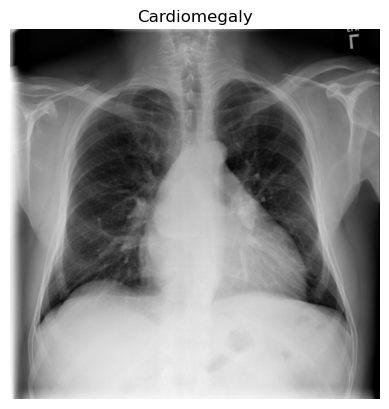

Image Index       00000001_000.png
Finding Labels        Cardiomegaly
Patient Gender                   M
Patient Age                     58
Name: 0, dtype: object


In [25]:
sample = subset.iloc[0]
img_path = f"../data/full_dataset/images/{sample['Image Index']}"

img = Image.open(img_path)

plt.imshow(img, cmap="gray")
plt.title(sample["Finding Labels"])
plt.axis("off")
plt.show()

print(sample[["Image Index", "Finding Labels", "Patient Gender", "Patient Age"]])

In [26]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ChestXrayDataset(
    csv_file="../data/Data_Entry_2017.csv",
    image_dir="../data/full_dataset/images",
    transform=transform
)

print("Dataset size:", len(dataset))
print("Disease labels:", dataset.disease_columns)

image, disease_labels, gender_label = dataset[0]
print("Image shape:", image.shape)
print("Disease label shape:", disease_labels.shape)
print("Gender label:", gender_label)

Dataset size: 4999
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
Image shape: torch.Size([3, 224, 224])
Disease label shape: torch.Size([14])
Gender label: tensor(1)


In [27]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskXRayModel(num_diseases=len(dataset.disease_columns)).to(device)
model.load_state_dict(torch.load("../outputs/xray_multitask_model.pt", map_location=device))
model.eval()

print("Model loaded on:", device)

/tmp/ipykernel_1981022/3327357027.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../outputs/xray_multitask_model.pt", map_location=dev

Model loaded on: cuda


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim

model = MultiTaskXRayModel(
    num_diseases=len(dataset.disease_columns)
).to(device)

disease_loss_fn = nn.BCEWithLogitsLoss()
gender_loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses = []

epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, disease_labels, gender_labels in train_loader:
        images = images.to(device)
        disease_labels = disease_labels.to(device)
        gender_labels = gender_labels.to(device)

        optimizer.zero_grad()

        disease_logits, gender_logits = model(images)

        disease_loss = disease_loss_fn(
            disease_logits,
            disease_labels
        )

        gender_loss = gender_loss_fn(
            gender_logits,
            gender_labels
        )

        loss = disease_loss + gender_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}"
    )

torch.save(
    model.state_dict(),
    "../outputs/xray_multitask_model.pt"
)

print(
    "Saved model to ../outputs/xray_multitask_model.pt"
)

Epoch 1, Train Loss: 0.8318
Epoch 2, Train Loss: 0.5210
Epoch 3, Train Loss: 0.4152
Epoch 4, Train Loss: 0.3147
Epoch 5, Train Loss: 0.2609
Epoch 6, Train Loss: 0.2418
Epoch 7, Train Loss: 0.2168
Epoch 8, Train Loss: 0.2126
Saved model to ../outputs/xray_multitask_model.pt


In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
all_gender_true = []
all_gender_preds = []

with torch.no_grad():
    for images, disease_labels, gender_labels in val_loader:
        images = images.to(device)

        disease_logits, gender_logits = model(images)
        gender_preds = torch.argmax(gender_logits, dim=1)

        all_gender_true.extend(gender_labels.tolist())
        all_gender_preds.extend(gender_preds.cpu().tolist())

print(classification_report(
    all_gender_true,
    all_gender_preds,
    target_names=["Female", "Male"]
))

cm = confusion_matrix(all_gender_true, all_gender_preds)
print(cm)

              precision    recall  f1-score   support

      Female       0.86      0.90      0.88       492
        Male       0.89      0.85      0.87       508

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.87      1000
weighted avg       0.88      0.88      0.87      1000

[[441  51]
 [ 74 434]]


In [41]:
for threshold in [0.5, 0.3, 0.2, 0.15, 0.1, 0.05]:
    disease_preds = (torch.sigmoid(all_disease_logits) > threshold).int()

    print("Threshold:", threshold)
    print("Predicted positives:", disease_preds.sum().item())
    print("Precision:", precision_score(all_disease_true.numpy(), disease_preds.numpy(), average="micro", zero_division=0))
    print("Recall:", recall_score(all_disease_true.numpy(), disease_preds.numpy(), average="micro", zero_division=0))
    print("F1:", f1_score(all_disease_true.numpy(), disease_preds.numpy(), average="micro", zero_division=0))
    print()

Threshold: 0.5
Predicted positives: 3
Precision: 1.0
Recall: 0.0043859649122807015
F1: 0.008733624454148471

Threshold: 0.3
Predicted positives: 146
Precision: 0.2671232876712329
Recall: 0.05701754385964912
F1: 0.09397590361445782

Threshold: 0.2
Predicted positives: 490
Precision: 0.2163265306122449
Recall: 0.15497076023391812
F1: 0.18057921635434412

Threshold: 0.15
Predicted positives: 882
Precision: 0.20634920634920634
Recall: 0.26608187134502925
F1: 0.23243933588761173

Threshold: 0.1
Predicted positives: 1610
Precision: 0.16459627329192547
Recall: 0.38742690058479534
F1: 0.23103748910200522

Threshold: 0.05
Predicted positives: 3705
Precision: 0.1184885290148448
Recall: 0.6418128654970761
F1: 0.20004556846662114



In [42]:
all_disease_logits = []
all_disease_true = []

with torch.no_grad():
    for images, disease_labels, gender_labels in val_loader:
        images = images.to(device)

        disease_logits, gender_logits = model(images)

        all_disease_logits.append(disease_logits.cpu())
        all_disease_true.append(disease_labels.int().cpu())

all_disease_logits = torch.cat(all_disease_logits)
all_disease_true = torch.cat(all_disease_true)

disease_threshold = 0.15
all_disease_preds = (torch.sigmoid(all_disease_logits) > disease_threshold).int()

disease_precision = precision_score(
    all_disease_true.numpy(),
    all_disease_preds.numpy(),
    average="micro",
    zero_division=0
)

disease_recall = recall_score(
    all_disease_true.numpy(),
    all_disease_preds.numpy(),
    average="micro",
    zero_division=0
)

disease_f1 = f1_score(
    all_disease_true.numpy(),
    all_disease_preds.numpy(),
    average="micro",
    zero_division=0
)

print("Disease Threshold:", disease_threshold)
print("Disease Precision:", disease_precision)
print("Disease Recall:", disease_recall)
print("Disease F1:", disease_f1)

Disease Threshold: 0.15
Disease Precision: 0.20634920634920634
Disease Recall: 0.26608187134502925
Disease F1: 0.23243933588761173


In [43]:
train_losses = []
val_loss = None
gender_acc = None

with open("../outputs/train_metrics.txt", "r") as f:
    for line in f:
        line = line.strip()

        if "Epoch" in line and "Train Loss:" in line:
            train_losses.append(float(line.split("Train Loss:")[1]))

        elif "Validation Loss:" in line:
            val_loss = float(line.split("Validation Loss:")[1])

        elif "Gender Accuracy:" in line:
            gender_acc = float(line.split("Gender Accuracy:")[1])

print("Train losses:", train_losses)
print("Validation loss:", val_loss)
print("Gender accuracy:", gender_acc)

Train losses: [0.7841, 0.5386, 0.4299, 0.3625]
Validation loss: 0.4499
Gender accuracy: 0.888


In [33]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from pathlib import Path

from xray_project.dataset import ChestXrayDataset
from xray_project.models import MultiTaskXRayModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [35]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = ChestXrayDataset(
    csv_file="../data/Data_Entry_2017.csv",
    image_dir="../data/full_dataset/images",
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 3999
Validation size: 1000


In [46]:
new_train_losses = [0.8318, 0.5210, 0.4152, 0.3147, 0.2609, 0.2418, 0.2168, 0.2126]

with open("../outputs/train_metrics.txt", "w") as f:
    for i, loss in enumerate(new_train_losses, start=1):
        f.write(f"Epoch {i} Train Loss: {loss:.4f}\n")
    f.write("Disease Threshold: 0.15\n")
    f.write("Disease Precision: 0.2063\n")
    f.write("Disease Recall: 0.2661\n")
    f.write("Disease F1: 0.2324\n")

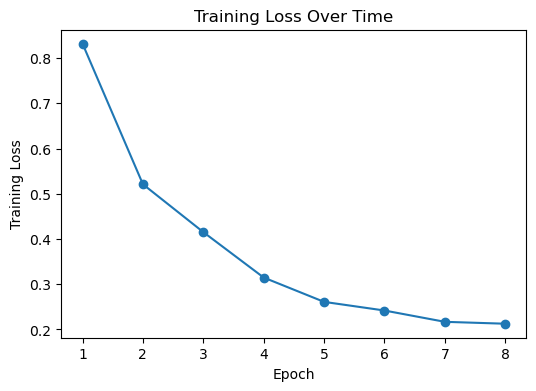

In [47]:
train_losses = []

with open("../outputs/train_metrics.txt", "r") as f:
    for line in f:
        if "Epoch" in line and "Train Loss:" in line:
            train_losses.append(float(line.split("Train Loss:")[1]))

plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Time")
plt.savefig("../outputs/training_loss.png", bbox_inches="tight")
plt.show()

In [48]:
with open("../outputs/train_metrics.txt", "w") as f:
    for i, loss in enumerate(train_losses, start=1):
        f.write(f"Epoch {i} Train Loss: {loss:.4f}\n")

In [49]:
with open("../outputs/train_metrics.txt", "r") as f:
    print(f.read())

Epoch 1 Train Loss: 0.8318
Epoch 2 Train Loss: 0.5210
Epoch 3 Train Loss: 0.4152
Epoch 4 Train Loss: 0.3147
Epoch 5 Train Loss: 0.2609
Epoch 6 Train Loss: 0.2418
Epoch 7 Train Loss: 0.2168
Epoch 8 Train Loss: 0.2126

